In [1]:

#step 1- Importing library
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
#step 2 importing dataset
df_main = pd.read_csv('/content/diabetes_data.csv')
df_extra = pd.read_csv('/content/diabetes_dataset_with_notes.csv')

df_main.head()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,TinglingHandsFeet,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,6000,44,0,1,2,1,32.985284,1,4.499365,2.443385,...,1,73.765109,0,0,0,1.782724,4.486980,7.211349,1,Confidential
1,6001,51,1,0,1,2,39.916764,0,1.578919,8.301264,...,0,91.445753,0,0,1,3.381070,5.961705,5.024612,1,Confidential
2,6002,89,1,0,1,3,19.782251,0,1.177301,6.103395,...,0,54.485744,0,0,0,2.701019,8.950821,7.034944,0,Confidential
3,6003,21,1,1,1,2,32.376881,1,1.714621,8.645465,...,0,77.866758,0,0,1,1.409056,3.124769,4.717774,0,Confidential
4,6004,27,1,0,1,3,16.808600,0,15.462549,4.629383,...,0,37.731808,0,0,0,1.218452,6.977741,7.887940,0,Confidential


In [ ]:
print("MAIN DATASET:\n", df_main.columns)
print("\nEXTRA DATASET:\n", df_extra.columns)

MAIN DATASET:
 Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'SocioeconomicStatus',
       'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption',
       'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryDiabetes', 'GestationalDiabetes',
       'PolycysticOvarySyndrome', 'PreviousPreDiabetes', 'Hypertension',
       'SystolicBP', 'DiastolicBP', 'FastingBloodSugar', 'HbA1c',
       'SerumCreatinine', 'BUNLevels', 'CholesterolTotal', 'CholesterolLDL',
       'CholesterolHDL', 'CholesterolTriglycerides',
       'AntihypertensiveMedications', 'Statins', 'AntidiabeticMedications',
       'FrequentUrination', 'ExcessiveThirst', 'UnexplainedWeightLoss',
       'FatigueLevels', 'BlurredVision', 'SlowHealingSores',
       'TinglingHandsFeet', 'QualityOfLifeScore', 'HeavyMetalsExposure',
       'OccupationalExposureChemicals', 'WaterQuality',
       'MedicalCheckupsFrequency', 'MedicationAdherence', 'HealthLiteracy',
       'Diagnosis', 'DoctorInCharge'],
      dtype=

In [3]:
df_main = df_main[['Age','Gender','BMI','Smoking','Hypertension',
                   'HbA1c','FastingBloodSugar','MedicationAdherence']]

df_main = df_main.rename(columns={
    'Age':'age',
    'Gender':'gender',
    'BMI':'bmi',
    'Smoking':'smoking',
    'Hypertension':'hypertension',
    'HbA1c':'hbA1c_level',
    'FastingBloodSugar':'blood_glucose_level',
    'MedicationAdherence':'adherence'
})

df_main = df_main.dropna()

df_main.head()

,age,gender,bmi,smoking,hypertension,hbA1c_level,blood_glucose_level,adherence
0,44,0,32.985284,1,0,9.283631,163.687162,4.486980
1,51,1,39.916764,0,0,7.326870,188.347070,5.961705
2,89,1,19.782251,0,0,4.083426,127.703653,8.950821
3,21,1,32.376881,1,0,6.516645,82.688415,3.124769
4,27,1,16.808600,0,0,5.607222,90.743395,6.977741


In [4]:
df_extra = df_extra[['hbA1c_level','blood_glucose_level']]
df_extra = df_extra.dropna()

In [5]:
df_main['hbA1c_level'] = df_extra['hbA1c_level'].sample(
    n=len(df_main), replace=True
).values

df_main['blood_glucose_level'] = df_extra['blood_glucose_level'].sample(
    n=len(df_main), replace=True
).values

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_main['gender'] = le.fit_transform(df_main['gender'])
df_main['smoking'] = le.fit_transform(df_main['smoking'])

In [7]:
df_main.info()
df_main.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1879 entries, 0 to 1878
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1879 non-null   int64  
 1   gender               1879 non-null   int64  
 2   bmi                  1879 non-null   float64
 3   smoking              1879 non-null   int64  
 4   hypertension         1879 non-null   int64  
 5   hbA1c_level          1879 non-null   float64
 6   blood_glucose_level  1879 non-null   int64  
 7   adherence            1879 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 117.6 KB


,age,gender,bmi,smoking,hypertension,hbA1c_level,blood_glucose_level,adherence
0,44,0,32.985284,1,0,7.5,159,4.486980
1,51,1,39.916764,0,0,4.8,158,5.961705
2,89,1,19.782251,0,0,4.8,160,8.950821
3,21,1,32.376881,1,0,4.8,100,3.124769
4,27,1,16.808600,0,0,5.7,100,6.977741


In [8]:
# Normalize adherence to 0–1 scale
df_main['adherence'] = df_main['adherence'] / 10

In [9]:
df_main['adherence'].describe()

,adherence
count,1879.000000
mean,0.495754
std,0.291093
min,0.000538
25%,0.242002
50%,0.484389
75%,0.751393
max,0.999716


In [10]:
#part-2 AI/ML [Logical part]
import numpy as np

# Higher adherence → more improvement
df_main['post_hba1c'] = df_main['hbA1c_level'] - (
    df_main['adherence'] * np.random.uniform(0.8, 1.5, len(df_main))
)

In [11]:
# If reduction > 1 → responder
df_main['responder'] = (
    df_main['hbA1c_level'] - df_main['post_hba1c'] > 1
).astype(int)

df_main['responder'].value_counts()

,count
responder,
0,1632
1,247


In [12]:
X = df_main[['age','bmi','hbA1c_level','blood_glucose_level',
             'hypertension','smoking','adherence']]

y = df_main['responder']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8962765957446809

Confusion Matrix:
 [[311   7]
 [ 32  26]]


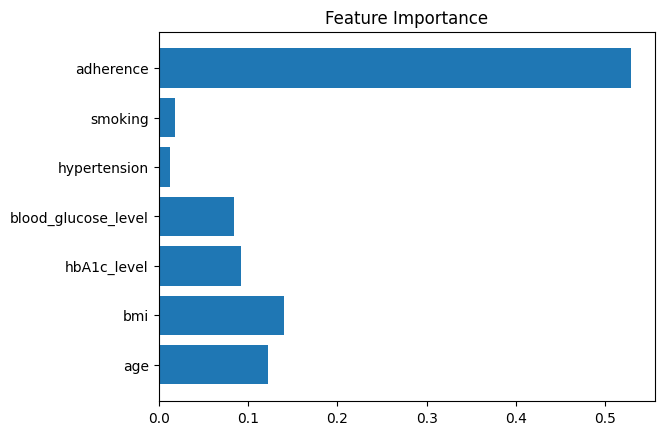

In [16]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

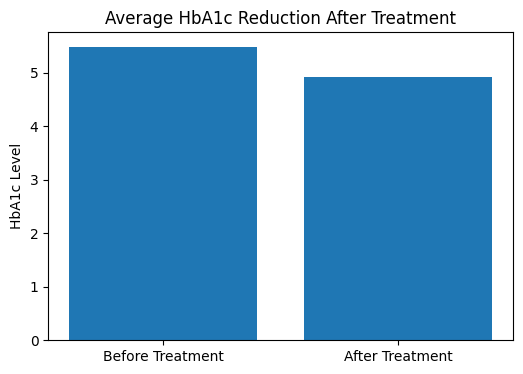

In [17]:
#part 3 Visualization
plt.figure(figsize=(6,4))

plt.bar(['Before Treatment','After Treatment'],
        [df_main['hbA1c_level'].mean(), df_main['post_hba1c'].mean()])

plt.title("Average HbA1c Reduction After Treatment")
plt.ylabel("HbA1c Level")
plt.show()

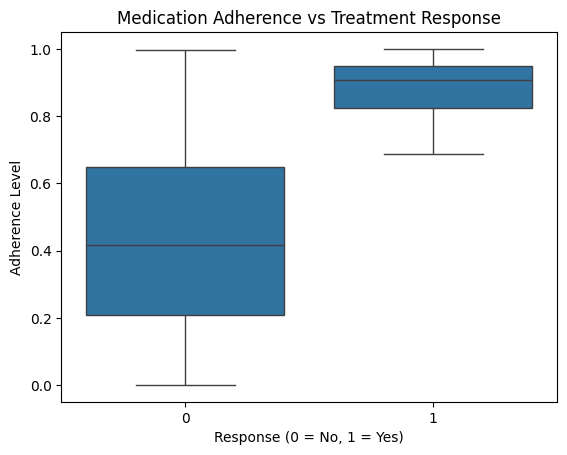

In [18]:
sns.boxplot(x='responder', y='adherence', data=df_main)
plt.title("Medication Adherence vs Treatment Response")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Adherence Level")
plt.show()


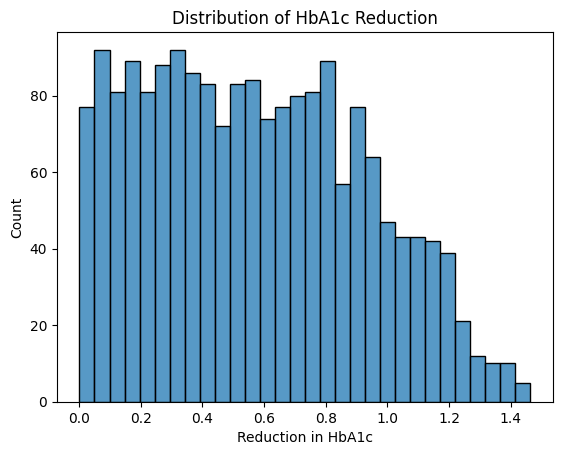

In [19]:
df_main['hba1c_reduction'] = df_main['hbA1c_level'] - df_main['post_hba1c']

sns.histplot(df_main['hba1c_reduction'], bins=30)
plt.title("Distribution of HbA1c Reduction")
plt.xlabel("Reduction in HbA1c")
plt.show()

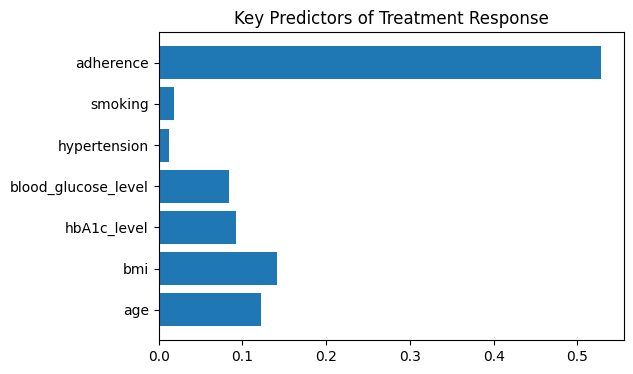

In [20]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
plt.barh(features, importances)
plt.title("Key Predictors of Treatment Response")
plt.show()

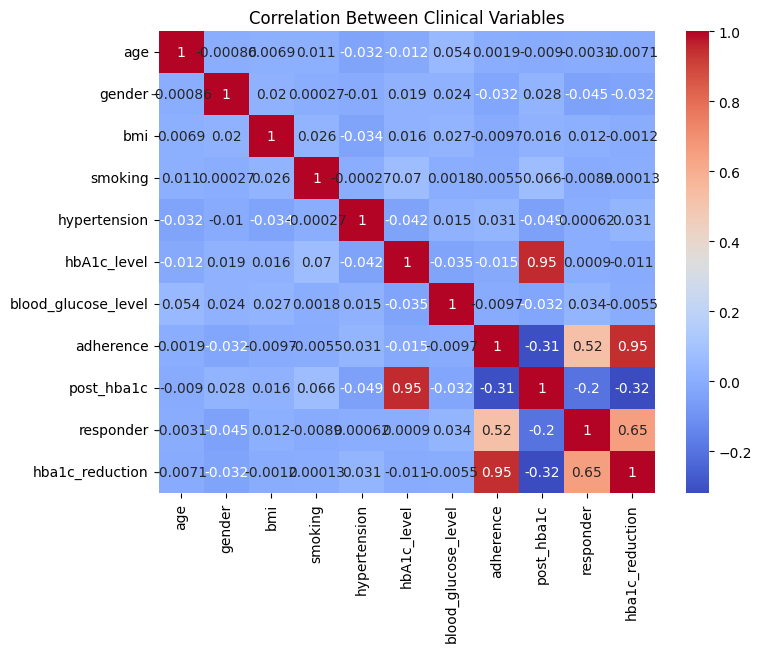

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df_main.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Clinical Variables")
plt.show()

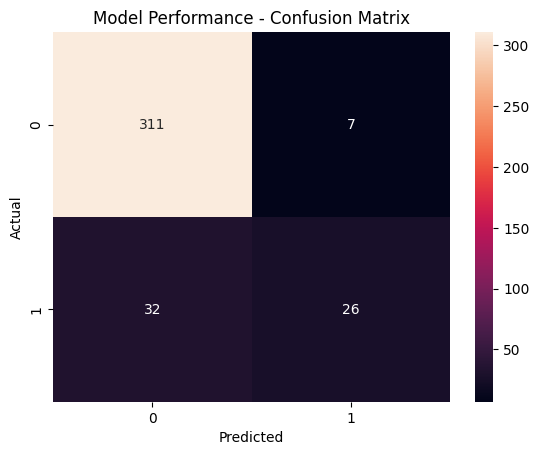

In [22]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Model Performance - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

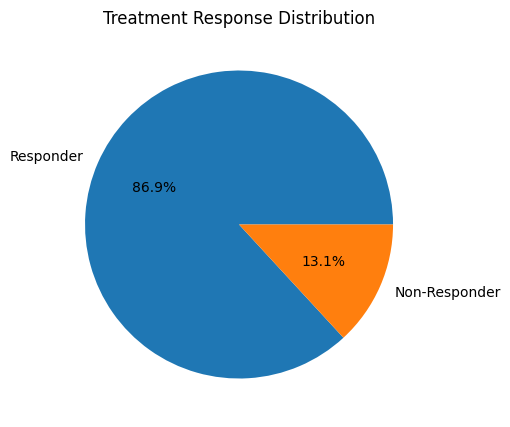

In [23]:
response_counts = df_main['responder'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(response_counts,
        labels=['Responder','Non-Responder'],
        autopct='%1.1f%%')

plt.title("Treatment Response Distribution")
plt.show()

In [24]:
df_main['adherence_group'] = pd.cut(
    df_main['adherence'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low','Medium','High']
)

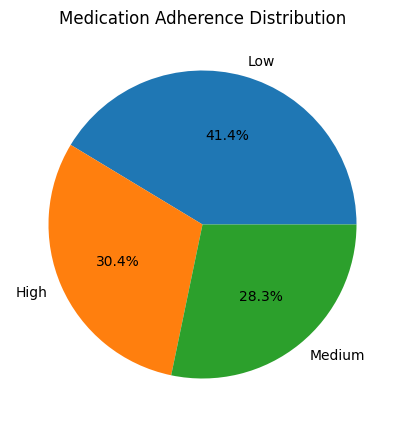

In [25]:
adherence_counts = df_main['adherence_group'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(adherence_counts,
        labels=adherence_counts.index,
        autopct='%1.1f%%')

plt.title("Medication Adherence Distribution")
plt.show()